<a href="https://colab.research.google.com/github/francescoboc/ML_course/blob/main/Lab5_NN_mnist_unsolved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5 - Neural networks

In this lab we will code from scratch a neural network that is able to classify with a high accuracy handwritten digits like these:

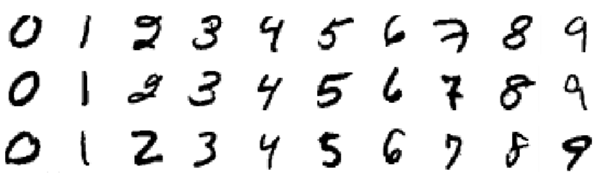

## Introduction

We, as humans, are able to recognize these digits without much effort. But beware: this ease is deceptive! In each hemisphere of our brain, we have a primary visual cortex, containing ~100 million neurons, with tens of billions of connections between them. And yet human vision involves not just the primary visual cortex, but an entire series of visual cortices, doing progressively more complex image processing.

The difficulty of visual pattern recognition becomes apparent if we attempt to write a computer program to recognize digits like those above: what seems easy when we do it ourselves suddenly becomes extremely difficult when we try to express it algorithmically. Simple intuitions about how we recognize shapes (e.g., a "6" has a loop at the bottom and a vertical stroke on the left) are quickly lost in a sea of exceptions and special cases.

Artificial neural networks (NNs) approach the problem in a different way: the idea is to take a large number of handwritten digits (the training dataset), and then develop a system which can *automatically learn* rules for recognizing those digits.

But *what is* a neural network? To get started, we need to introduce a type of artificial neuron called a *perceptron*.

## Perceptrons

A perceptron is a function that takes several *binary* inputs $x_1, x_2, \dots$ and produces a single *binary* output:

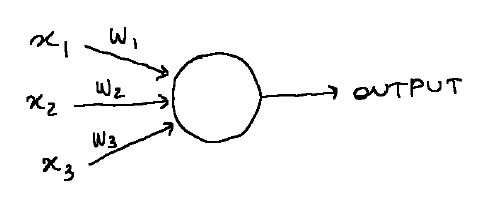

The *weights* $w_1, w_2, \dots$ of the perceptron are real numbers expressing the importance of the respective inputs to the output.

The output, $0$ or $1$, is determined whether the weighted sum $\sum_j w_j x_j$ is less or greater than a *threshold* value, a real number which is a parameter of the perceptron:

$$\mathrm{output} = \begin{cases}
    0 & \text{if } \sum_j w_j x_j \leq \mathrm{threshold},\\
    1 & \text{if } \sum_j w_j x_j > \mathrm{threshold}.
\end{cases}$$

Although it is very simple, the perceptron can already be used as a model for decision making. Let's look at a little example.

> There's a music festival and you are trying to decide whether or not to go. You might take your decision by weighing up three factors:
> 1.   Is the weather good? $\rightarrow x_1$
2.   Does your partner want to come? $\rightarrow x_2$
3.   Is the festival reachable by bus? $\rightarrow x_3$
>
> These three factors are the binary variables. Now, we can use the weights to model how much we care about the variables, e.g.:
>
>*   $w_1=6 \rightarrow$ The weather matters a lot to you
*   $w_2=2$
*    $w_3=2$
>
>Let's suppose that we set the threshold $=5$, then the output will be $1$ if the weather is good and $0$ if it's bad. In this case, the values of $x_2$ and $x_3$ will not change the output. By changing the weights and the threshold, we can obtain different models of decision making. E.g., with threshold $=3$, the output will be $1$ if the weather is good *or* when both your partner wants to come and the festival is reachable by bus. Lowering the threshold means that you are more willing to go to the festival.

$\rightarrow$ **Exercise**: can you find the weights and threshold to make a perceptron with 2 binary inputs reproduce the [NAND gate truth table](https://en.wikipedia.org/wiki/NAND_gate)?

The perceptron is a very simple model, but it's plausible that a complex network of perceptrons can make more subtle decisions:

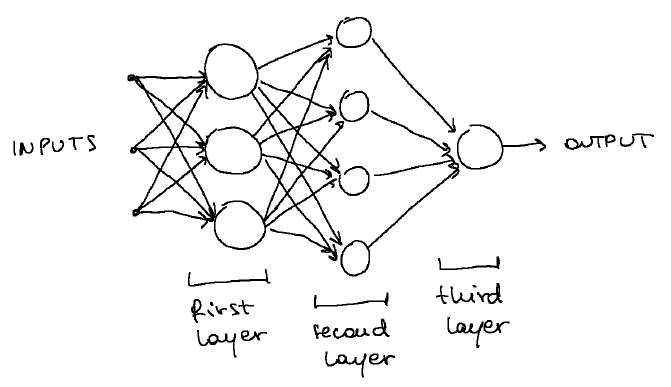

The perceptrons in the first layer are making very simple decisions by weighing the inputs. The ones in the second layer are making decisions by weighing up the results of the first layer, hence making decisions at a more abstract level than the first layer. Even more complex decisions are made by the perceptron in the third (or _output_) layer.

The layers that are in between the input and the output layer (the first and second layer, in the network above) are called _hidden_ layers.

Note that the units in the input layer are _not_ perceptrons, but _input neurons_ (i.e., special units which are simply defined to output the desired values $x_1, x_2, \dots$).

The architecture described in the figure above, where the output of one layer is used as input for the next layer (there are no _loops_ in the network) is that of a _feedforward_ NN. There are other models where loops are possible, such as _recurrent_ NNs, but we will not address them in this lab.

A last bit of terminology: when each neuron in a given layer is connected to every neuron in the next layer, the network is called _dense_ or _fully connected_.

Before continuing, let's simplify the notation a bit. First, we write the weighted sum as a dot product, $\underline{w} \cdot \underline{x} = \sum_j w_j x_j$, where $\underline{w}$ and $\underline{x}$ are vectors whose components are the weights and inputs. Then, we move the threshold to the left hand side of the inequality and we replace it with the so-called _bias_: $b=-$threshold. With these changes, the perceptron rule can be rewritten:

$$\mathrm{output} = \begin{cases}
    0 & \text{if } \underline{w} \cdot \underline{x} +b \leq 0,\\
    1 & \text{if } \underline{w} \cdot \underline{x} +b > 0.
\end{cases}$$

We will now introduce another type of artificial neuron, which is similar to a perceptron, but modified so that small changes in its weights and biases causes only a small change in the output. As we wil see, this property allows a network of artificial neurons to _learn_.

## Sigmoid neurons

Sigmoid neurons differ from perceptrons in two aspects:
1.   The inputs $x_1, x_2, \dots$ are not binary but can take any value between $0$ and $1$,
2.   The output is also not binary but it's $\sigma(\underline{w} \cdot \underline{x} +b)$, where $\sigma$ is the _sigmoid function_:
$$\sigma(z)=\frac{1}{1+e^{-z}}\,.$$

The sigmoid function is a smoothed versions of the step function, which is the one used by the perceptron:

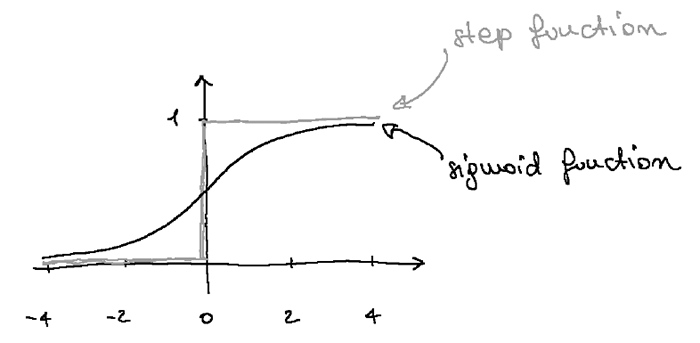

$\rightarrow$ **Exercise**: show that, in the limits of $z$ very positive or very negative, the behavior of a sigmoid neuron is the same as that of a perceptron.

# A simple NN to classify handwritten digits

With sigmoid neurons, we can start building our NN to classify handwritten digits. We will use the [MNIST dataset](https://en.wikipedia.org/wiki/MNIST_database) which is made up of $60000$ training images and $10000$ test images, with their corresponding labels. The images are $28 \times 28$ pixels and in greyscale.

We will use the following architecture for the NN:
-   The input layer will contain $28 \times 28 = 784$ input neurons (one for each pixel),
-   Then we will have one hidden layer with $n_h$ neurons (we wil try different values of $n_h$),
-   The output layer will contain $10$ neurons (one for each digit): the neuron with the highest output will determine which digit was predicted by the network.

As in many other optimization procedures we have seen in previous labs, the training of the NN is achieved with the _gradient descent_ algorithm.

##Learning with gradient descent

Let us call $\underline{x}$ a training input. It will be a $784$-dimensional vector, where each element represents the grey value (between $0$ and $1$) of the corresponding pixel.
The corresponding _desired_ output of the network is $\underline{y}(\underline{x})$, where $\underline{y}$ is a $10$-dimensional vector.

For example, if $\underline{x}$ is a "6", then $\underline{y}=(0,0,0,0,0,0,1,0,0,0)^T$.

Our aim is to find a set of weights and biases so that the output of the network best approximates $\underline{y}(\underline{x})$. To quantify how well the network is doing we define the _cost function_
$$
C(\underline{w}, \underline{b}) = \frac{1}{2n}\sum_{\underline{x}}|| \underline{y}(\underline{x}) - \underline{a}(\underline{x}, \underline{w}, \underline{b}) ||^2\, ,
$$
where $\underline{w}$ and $\underline{b}$ are vectors whose components are respectively all network weights and biases, $n$ is the number of training inputs, $\underline{a}$ is the vector of outputs (or _activations_) from the network when $\underline{x}$ is input, and the sum is over all training inputs. $C$ is called _quadratic cost function_ or _mean squared error_ (MSE).

If we could calculate the gradient of the cost function $\nabla C$, whose components are the partial derivatives ${\partial C}/{\partial w}, {\partial C}/{\partial b}$ for all the components $w, b$ of the $\underline{w}, \underline{b}$ vectors, then we would know how to update the weights and biases so that the cost function decreases:
$$
w \rightarrow w'= w - \eta \frac{\partial C}{\partial w}\,,\\
b \rightarrow b'= b - \eta \frac{\partial C}{\partial b}\,,
$$
where $\eta$ is a (small) parameter called _learning rate_. This is the usual gradient descent (GD) update rule.

Now, there's a technical problem in applying this update rule to a dataset like ours ($60000$ images): the cost function $C$ has the form
$$
C=\frac{1}{n}\sum_\underline{x}C_\underline{x}\,,
$$
that is, it's an average over the costs
$$
C_\underline{x} = \frac{1}{2}|| \underline{y}(\underline{x}) - \underline{a}||^2
$$
of each individual training sample $\underline{x}$. This means that to compute $\nabla C$ we need to compute all the gradients $\nabla C_\underline{x}$ and then average them. When the training dataset is big, this operation can be computationally very costly!

One solution is _stochastic_ gradient descent (SGD): the idea is to compute $\nabla C_\underline{x}$ only for a small subset of randomly chosen training samples and then take the average to obtain an _estimate_ of $\nabla C$. The randomly selected inputs are called _mini-batch_ and are labelled as $\underline{X}_1, \underline{X}_2, \dots, \underline{X}_m$. So we have
$$
\frac{1}{m}\sum_{i=1}^m \nabla C_{\underline{X}_i} \simeq \frac{1}{n} \sum_\underline{x}C_\underline{x} = \nabla C\,.
$$
We can then adapt our update rule to use SGD on a randomly chosen mini-batch:
$$
w \rightarrow w'= w - \frac{\eta}{m} \sum_{i=1}^m\frac{\partial C_{\underline{X}_i}}{\partial w}\,,\\
b \rightarrow b'= b - \frac{\eta}{m} \sum_{i=1}^m\frac{\partial C_{\underline{X}_i}}{\partial b}\,,
$$
where the sums are over all the training samples in the current mini-batch. This is the stochastic gradient descent (SGD) update rule.

The next update will be done on another random mini-batch, until all the training inputs have been used. When this happens, we say that one _epoch_ of training has been completed.

At this point we can start coding the main function to train the neural network (**fill in where there are dots**):

In [ ]:
import numpy as np

# Train the neural network using mini-batch stochastic gradient descent
def train_network_SGD(sizes, training_data, test_data, epochs, mini_batch_size, learning_rate):
    # Get number of layers from the 'sizes' list
    num_layers = ...
    # Initialize weights and biases vectors randomly
    weights = [np.random.randn(y, x) for x, y in zip(sizes[:-1], sizes[1:])]
    biases = [np.random.randn(y, 1) for y in sizes[1:]]
    # Extract number of training  and test samples
    n = ...
    n_test = ...
    # For each epoch
    for j in range(epochs):
        # Shuffle the training dataset and partition it in mini-batches
        np.random.shuffle(training_data)
        mini_batches = [training_data[k:k+...] for k in range(..., ..., ...)]
        # Run a single step of SGD on every mini batch to update the weights and biases
        for mini_batch in mini_batches:
            weights, biases = update_mini_batch(mini_batch, learning_rate, weights, biases, num_layers)
        # At the end of each epoch, evaluate the accuracy of the network on the test dataset
        # The evaluate_wrong() function returns the test samples that were wrongly predicted
        wrong_samples = evaluate_wrong(test_data, weights, biases)
        n_correct = n_test - len(wrong_samples)
        print(f'Epoch {j+1}/{epochs}. Accuracy: {n_correct/n_test}')
    return weights, biases, wrong_samples

The parameters of this function are:
*   `sizes`: a list of integers corresponding to the number of neurons in each layer of the NN. E.g., `[420, 69, 10]` corresponds to a three-layer NN with an input layer of $420$ neurons, then a hidden layer with $69$ neurons and then an output layer with $10$ neurons,
*   `training_data`: a list of tuples `(x, y)` representing the training inputs and the desired outputs,
*   `test_data`: a list of tuples `(x, y)` representing the test inputs and the desired outputs (this is _only_ needed for tracking the accuracy during training),
*   `epochs`: number of epochs,
*   `mini_batch_size`: number of training samples in each mini-batch,
*   `learning_rate`: learning rate $\eta$.

The function returns the updated `weights` and `biases` as well as the test samples `wrong_samples` that were wrongly predicted after the last training epoch.

Notes:
*    The weights and biases of the network are initialized randomly, using a Gaussian distribution with mean $0$, and variance $1$,
*    The first layer is assumed to be an input layer, and by convention we don't set any biases for those neurons, since biases are only ever used in computing the outputs from later layers,
*    Similarly, we don't set weights for the last (output) layer,
Note that we are using the list comprehension Python notation for compactness.
*    The network is evaluated against the test data after each epoch, and the accuracy at the current epoch is printed out (this is only needed for tracking progress, but it slows things down considerably!),
*    To be more concise, we have occasionally used Python's [list comprehension](https://docs.python.org/3/tutorial/datastructures.html#list-comprehensions) syntax and the built-in [`zip()`](https://docs.python.org/3/library/functions.html#zip) function.

We have yet to define the functions `update_mini_batch()`, which performs a single step of SGD on a mini-batch and updates the weights and biases according to the update rule defined above, and `evaluate_wrong()`, which evaluates the accuracy of the neural network on the datatest set and returns the test samples that were wrongly classified.

Let's start from the `update_mini_batch()` function:

In [ ]:
# Update the network's weights and biases according to a single iteration of SGD on a mini-batch
def update_mini_batch(mini_batch, learning_rate, weights, biases, num_layers):
    # Initialize empty lists for the gradient components
    nabla_b = [np.zeros(b.shape) for b in biases]
    nabla_w = [np.zeros(w.shape) for w in weights]
    # For every sample in the mini-batch
    for x, y in mini_batch:
        # Calculate the gradient of the cost function using the backpropagation algorithm
        delta_nabla_b, delta_nabla_w = backprop(x, y, weights, biases, num_layers)
        nabla_b = [nb+dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
        nabla_w = [nw+dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]
    # Apply the update rule to each component of the weights and biases vectors
    weights = [w-... for w, nw in zip(weights, nabla_w)]
    biases = [b-... for b, nb in zip(biases, nabla_b)]
    # Return the updated weights and biases
    return weights, biases

Most of the work in this function is done by the line
```
delta_nabla_b, delta_nabla_w = backprop(x, y, weights, biases, num_layers)
```
which invokes something called the _backpropagation_ algorithm, which is a fast way to compute the gradient of the cost function.

##The backpropagation algorithm

We will now give an outline of the reasoning to obtain the equations of the backpropagation algorithm. The reader interested in a more formal derivation can refer to chapter 2 of the book [Neural Networks and Deep Learning by Michael Nielsen](https://static.latexstudio.net/article/2018/0912/neuralnetworksanddeeplearning.pdf).

###Appetizer: One-neuron-per-layer network
To understand how this method works, let's start by considering an extremely simple network with two hidden layers and just one neuron in each layer:

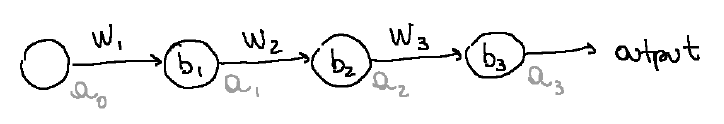

The cost function for this network is a function of only $6$ variables: $C(w_1,w_2,w_3,b_1,b_2,b_3)$. Our goal is to understand how sensitive is $C$ to these variables, so we will know which adjustments to the weights and biases will cause the most efficient decrease to the cost function.

As before, the _desired_ output for a given sample $x$ is $y(x)$. Note that in this case $x$ and $y$ are scalars. The cost for a single training sample $x_0$ is simply
$$C_0(w_1,w_2,w_3,b_1,b_2,b_3)=\frac{1}{2}(a_3-y(x_0))^2\,,
$$
where $a_3$ is the activation of the neuron in the last (output) layer, and is equal to
$$a_3= \sigma(w_3 a_2 + b_3)=\sigma(z_3)\,,
$$
with
$$z_3 = w_3 a_{2} + b_3\,.$$

We can see that $C_0$ is a function of $a_3$, which in turn is a function  $z_3$ , which in turn is a function of $w_3$, $a_2$ and $b_3$. Let's start from the last layer $L=3$. We can calculate the derivative of $C_0$ with respect to $w_3$ by applying the _chain rule_:
$$
\frac{\partial C_0}{\partial w_3}= \frac{\partial C_0}{\partial a_3} \frac{\partial a_3}{\partial z_3} \frac{\partial z_3}{\partial w_3} = \delta_3 a_2\,,
$$
where we have defined
$$
\delta_3 = \frac{\partial C_0}{\partial a_3} \frac{\partial a_3}{\partial z_3} = \dots\,.
$$
$\rightarrow$ **Exercise**: compute $\delta_3$.

Similarly, we can calulate the derivative of $C_0$ with respect to $b_3$ as
$$
\frac{\partial C_0}{\partial b_3}= \frac{\partial C_0}{\partial a_3} \frac{\partial a_3}{\partial z_3} \frac{\partial z_3}{\partial b_3} = \delta_3\,.
$$

Now let's move on the second-to-last layer $L-1=2$:
$$
\frac{\partial C_0}{\partial w_2}= \frac{\partial C_0}{\partial a_3} \frac{\partial a_3}{\partial z_3} \frac{\partial z_3}{\partial a_2} \frac{\partial a_2}{\partial z_2} \frac{\partial z_2}{\partial w_2}= \delta_2 a_1\,,
$$
where we have defined
$$
\delta_2 = \frac{\partial C_0}{\partial a_3} \frac{\partial a_3}{\partial z_3} \frac{\partial z_3}{\partial a_2} \frac{\partial a_2}{\partial z_2} = \delta_3 \frac{\partial z_3}{\partial a_2} \frac{\partial a_2}{\partial z_2} = \delta_3 \times \dots\,.
$$
$\rightarrow$ **Exercise**: compute $\delta_2$.

And
$$
\frac{\partial C_0}{\partial b_2}= \frac{\partial C_0}{\partial a_3} \frac{\partial a_3}{\partial z_3} \frac{\partial z_3}{\partial a_2} \frac{\partial a_2}{\partial z_2} \frac{\partial z_2}{\partial b_2}= \delta_2\,.
$$

Finally, we move on to the first layer $L-2=1$:
$$
\begin{align}
\frac{\partial C_0}{\partial w_1}&= \dots = \delta_1 a_0\,,\\
\frac{\partial C_0}{\partial b_1}&= \dots = \delta_1\,,\\
\end{align}
$$
with
$$
\delta_1 = \delta_2 \times \dots
$$
$\rightarrow$ **Exercise**: compute $\delta_1$.

That's it! We have computed all the components of
$\nabla C_0=\left(\frac{\partial C_0}{\partial w_1}, \frac{\partial C_0}{\partial w_2}, \frac{\partial C_0}{\partial w_3}, \frac{\partial C_0}{\partial b_1}, \frac{\partial C_0}{\partial b_2}, \frac{\partial C_0}{\partial b_3} \right)$.
Note that we went _backwards_, starting from the last layer $L$ and ending in the first layer, hence the name of the algorithm.

From this simple example you should be able to infer the backpropagation equations for a network with $L$ layers and one neuron per layer:
$$C_0 = \frac{1}{2}(a_L-y(x_0))^2\,,
$$
with
$$
a_L = \sigma(w_L a_{L-1} + b_L)=\sigma(z_L)\,.
$$

Then:
$$
\begin{align}
\frac{\partial C_0}{\partial w_l} &= \delta_l \,a_{l-1}\,,\\
\frac{\partial C_0}{\partial b_l} &= \delta_l\,,\\
\end{align}
$$
with
$$
\delta_l = \delta_{l+1} \times \dots\,,
$$
and, for the last layer $L$,
$$
\delta_L = \dots \,.
$$

$\rightarrow$ **Exercise**: write the backpropagation equations for $\delta_l$ and $\delta_L$.

###Main dish: Multiple-neurons-per-layer network

To generalize this reasoning to a network with multiple neurons per layer, we have to add some more indices:

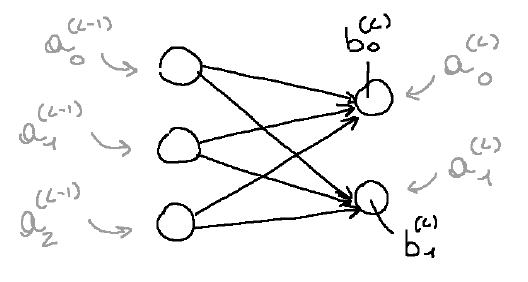

Note that we now write the layer index $L$ as superscript in parentheses, while the subscript indicates the neuron in the layer (we start counting neurons from $0$ instead of $1$ to match Python syntax):

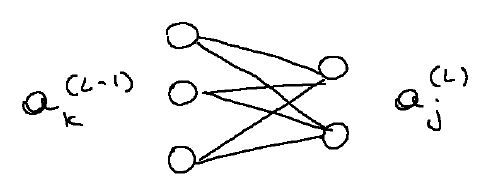

We use $k$ for the neurons in layer $L-1$ and $j$ for the ones in layer $L$.

For the cost, we now have to sum over all neurons in the last layer $n_L$:
$$C_0=\dfrac{1}{2}\sum_{j=0}^{n_L-1}(a_j^{(L)}-y_j)^2\,,$$
or, in vector representation:
$$C_0 = \dfrac{1}{2}||\underline{a}^{(L)}- \underline{y} ||^2\,,
$$
where we have defined $\underline{a}^{(L)}$ as the activation vector of the last layer, whose components are the activations $a_j^{(L)}$.

The weight connecting the $k$-th neuron in layer $L-1$ to the $j$-th neuron in layer $L$ is labeled as:

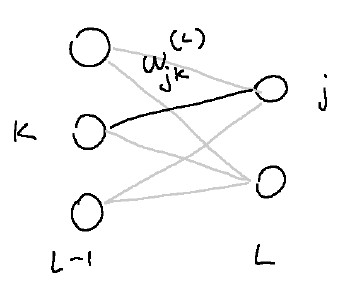

(The indices $j$ and $k$ might seem reversed, but this order will make the matrix representation easier.)

Hence, the function $z^{(L)}$ becomes
$$z_j^{(L)} = \sum_{k=0}^{n_{L-1}-1}w_{jk}^{(L)}a_k^{(L-1)} + b_j^{(L)}\,.
$$
Note that we are now summing over all inputs to neuron $j$ coming from the previous layer, times the corresponding weights, and then we are adding the bias of the neuron $b_j^{(L)}$.

$\rightarrow$ **Exercise**: write down explicitly all terms of the function $z_j^{(L)}$ for neuron $j$ in layer $L$ represented in the figure above.

In vectorized form, $\underline{z}^{(L)}$ can be written as
$$\underline{z}^{(L)} = \underline{W}^{(L)} \underline{a}^{(L-1)} + \underline{b}^{(L)}\,,
$$
where we have defined the weight matrix $\underline{W}^{(L)}$ for each layer $L$ (the entries of this matrix are the weights connecting to the $L$-th layer of neurons: the entry in the $j$-th row and $k$-th column is $w_{jk}^{(L)}$) ,and the bias vector $\underline{b}^{(L)}$, whose components are the biases $b_j^{(L)}$.

With this notation, the activation vector of the output layer $\underline{a}^{(L)}$ is simply
$$\underline{a}^{(L)} = \sigma(\underline{z}^{(L)})\,,$$
where each component is given by
$$a_j^{(L)} = \sigma(z_j^{(L)})\,.$$

$\rightarrow$ **Exercise**: by comparison with the case of a network with one neuron per layer, check that the backpropagation equations for a network with multiple neurons per layer correspond to
$$
\begin{align}
\frac{\partial C_0}{\partial w_{jk}^{(l)}} &= \delta_j^{(l)} \,a_{k}^{(l-1)}\,,\\
\frac{\partial C_0}{\partial b_{j}^{(l)}} &= \delta_j^{(l)} \,,\\
\underline{\delta}^{(l)} &= ((\underline{W}^{(l+1)})^T \underline{\delta}^{(l+1)}) \odot \sigma'(\underline{z}^{(l)}) \,,\\
\underline{\delta}^{(L)} &= \nabla_{\underline{a}} C_0 \odot \sigma'(\underline{z}^{(L)}) \,,
\end{align}
$$
where $\nabla_{\underline{a}} C_0$ is defined to be a vector whose components are the partial derivatives $\partial C_0/\partial a_j^{(l)}$ and the symbol $\odot$ denotes the elementwise product of two vectors.

We now have all the ingredients to write a function that implements the backpropagation algorithm:

In [ ]:
# Run the backpropagation algorithm on a single training input (x, y)
def backprop(x, y, weights, biases, num_layers):
    # Initialize empty lists for gradient components (same shape as `biases` and `weights`)
    nabla_b = [np.zeros(b.shape) for b in biases]
    nabla_w = [np.zeros(w.shape) for w in weights]
    # Set the activation of the input layer a^(1) equal to the input x
    activation = x
    # Initialize lists to store all the activations and all the z vectors, layer by layer
    activations = [x]
    zs = []

    # FEEDFORWARD PASS
    # For every W^(L) matrix and b^(L) vector
    for w, b in zip(weights, biases):
        # Compute the z^(L) vector and store it in the corresponding list
        z = ...
        zs.append(z)
        # Compute the a^(L) vector and store it in the corresponding list
        activation = ...
        activations.append(activation)
    # Compute the delta vector of the output layer delta^(L)
    delta = cost_derivative(activations[-1], y) * sigmoid_prime(zs[-1])
    # And the corresponding gradient components
    nabla_b[-1] = ...
    nabla_w[-1] = ...

    # BACKWARD PASS
    # For each layer l=L-1, L-2,... (we already computed the gradient for the output layer L)
    for l in range(2, num_layers):
        z = zs[-l]
        sp = sigmoid_prime(z)
        # Compute the delta vector of the current layer delta^(l)
        delta = ...
        # And the corresponding gradient components
        nabla_b[-l] = ...
        nabla_w[-l] = ...

    # Return a tuple (nabla_b, nabla_w) representing the gradient of the cost function
    # (nabla_b and nabla_w are layer-by-layer lists of numpy arrays)
    return (nabla_b, nabla_w)

Note that, to cycle through the layers of the network in the backward pass, we are using Python's _negative index_ syntax. Negative indexes mean that we can access the elements of a list starting from the end instead of the beginning. E.g., `list[-1]` refers to the last element of a `list`, `list[-2]` is the second to last, and so on.

Now we just need to define the functions for the sigmoid $\sigma$, its first derivative $\sigma'$ and the derivative of the cost function with respect to the output activations:

In [ ]:
# Sigmoid function
def sigmoid(z):
    return ...

# Derivative of the sigmoid function
def sigmoid_prime(z):
    return ...

# Derivative of the cost function with respect to `a` for the output activations
def cost_derivative(output_activations, y):
    return ...

Finally, we need the function `evaluate_wrong()` to evaluate the accuracy of the network on the test dataset:

In [ ]:
# Evaluate the accuracy of the network and return the test inputs that were wrongly predicted
def evaluate_wrong(test_data, weights, biases):
  # Initialize empty list for the wrongly-classified test samples
    wrong_samples = []
    for (x, y) in test_data:
        # Compute the output of the newtork for the input `x`
        a = feedforward(x, weights, biases)
        # And reformat it to one-hot encoding
        a_onehot = np.zeros((10, 1))
        a_onehot[np.argmax(a)] = 1
        # Check the NN prediction by comparing all the elements of the vectors `a_onehot` and `y`
        if not np.all(a_onehot==y): wrong_samples.append((x, a_onehot))
    return wrong_samples

# Return the output of the network if `a` is input
def feedforward(a, weights, biases):
    for w, b in zip(weights, biases):
        a = ...
    return a

Note that, in the `evaluate_wrong()` function, the output of the neural network is reformatted as a vector whose elements are all zeros except the one corresponding to the index of the output neuron that has the highest activation (one-hot encoding). This allows to compare the output $\underline{a}(\underline{x})$ (i.e. the predicted digit) and the correct digit $\underline{y}(\underline{x})$.

# Training the neural network

After all this hard work, we can finally train our neural network! But first, we need to load and reformat the MNIST dataset correctly:

In [ ]:
# If you use Google Colab, use this function to upload mnist.pkl.gz (might take some minutes)
# Otherwise, comment these lines and move mnist.pkl.gz to the same folder as the notebook
from google.colab import files
files.upload()

These functions are needed to reformat the dataset properly in order to work with the neural network functions defined earlier:

In [ ]:
import pickle, gzip

# Load and decompress MNIST dataset from given path
def load_mnist_data(path):
    f = gzip.open(path, 'rb')
    u = pickle._Unpickler(f)
    u.encoding = 'latin1'
    tr_d, va_d, te_d = u.load()
    # Merge the validation dataset with the test dataset
    tr_d = tr_d + va_d
    f.close()
    print('MNIST dataset loaded\n')
    return tr_d, te_d

# Vectorize the labels `y` and reformat the datasets into tuples (x, y)
def reformat(tr_d, te_d):
    training_inputs = [np.reshape(x, (784, 1)) for x in tr_d[0]]
    training_results = [vectorized_result(y) for y in tr_d[1]]
    training_data = list(zip(training_inputs, training_results))
    test_inputs = [np.reshape(x, (784, 1)) for x in te_d[0]]
    test_results = [vectorized_result(y) for y in te_d[1]]
    test_data = list(zip(test_inputs, test_results))
    return training_data, test_data

# Convert a label to a vector (one-hot encoding)
def vectorized_result(j):
    result = np.zeros((10, 1))
    result[j] = 1
    return result

Let's load the MNIST dataset, reformat it, and inspect the first 5 samples in the training set:

In [ ]:
import matplotlib.pyplot as plt

# Load and reformat MNIST datasets
path = 'mnist.pkl.gz'
training_data_raw, test_data_raw = load_mnist_data(path)
training_data, test_data = reformat(training_data_raw, test_data_raw)

# Visualize the first 5 samples of the training dataset
fig, axs = plt.subplots(1, 5, sharey=True)
fig.suptitle('First 5 samples of the training set:', y=0.7)
for i in range(5):
  axs[i].imshow(training_data[i][0].reshape(28,28), cmap='gray_r')
  # Reconvert the one-hot encoded label `y` into the corresponding digit
  axs[i].set_title(f'y={np.argmax(training_data[i][1])}')

Now we can define the architecture of the neural network and its training parameters. As mentioned before, we use the following architecture:
*   Input layer with 784 input neurons,
*   One hidden layer with  $n_h=10$  neurons
*   Output layer with 10  neurons

Then, we can call the function `train_network_SGD()` to train the NN.

In [ ]:
# Number of neurons in the (first) hidden layer
nh = 10

# Set the architecture of the NN by defining the size of each layer (i.e. the number of neurons)
sizes = [784, nh, 10]

# Set parameters for training
epochs = 5
mini_batch_size = 5
learning_rate = 2.0

# Train the NN with mini-batch SGD
weights, biases, wrong_samples = train_network_SGD(sizes, training_data, test_data, epochs, mini_batch_size, learning_rate)

## Visualizing the hidden layer

To have a sense of what our NN is learning we can visualize the weight matrix of the hidden layer $\underline{W}^{(1)}$. The $i$-th row of this matrix is a $784$-dimensional vector that contain the weigths from each input pixel to the $i$-th neuron in the hidden layer. Pixels that are weighted more will more likely cause the hidden neuron to be activated (note that this only a _partial_ representation of the activation of the hidden neurons, because we are ignoring the bias term). In other words, higher weights correspond to pixels to which the $i$-th neuron is more "sensitive".

Thus, we can we can reshape this vector into a $28 \times 28$ image and display it. We should see that the hidden neurons corresponds roughly to _detectors_ that look for strokes and other patterns in the input:

In [ ]:
fig, axs = plt.subplots(2, 5, sharey=True)
fig.suptitle('Weights of the 10 neurons in the hidden layer:', y=0.9)
for i in range(10):
    if i<5:
        axs[0][i].imshow(weights[0][i].reshape(28,28))
        axs[0][i].set_title(f'Neuron {i+1}')
    else:
        axs[1][i-5].imshow(weights[0][i].reshape(28,28))
        axs[1][i-5].set_title(f'Neuron {i+1}')
fig.subplots_adjust(hspace=-0.3)

## Visualizing the test samples where the NN failed

We can also inspect the test samples that were misclassified by the NN. If the training was successful, we should see that these samples correspond to particularly poorly written digits:

In [ ]:
fig, axs = plt.subplots(2, 5, sharey=True)
fig.suptitle('First 10 wrongly classified images:', y=0.9)
for i in range(10):
    if i<5:
        axs[0][i].imshow(wrong_samples[i][0].reshape(28,28), cmap='gray_r')
        axs[0][i].set_title(f'a={np.argmax(wrong_samples[i][1])}')
    else:
        axs[1][i-5].imshow(wrong_samples[i][0].reshape(28,28), cmap='gray_r')
        axs[1][i-5].set_title(f'a={np.argmax(wrong_samples[i][1])}')
fig.subplots_adjust(hspace=-0.3)

## Exercises
Now that we have a working code to train a NN, we can test the performance of the network as the architecture and training parameters change:

1.   Try changing the number of hidden neurons $n_h$: what is the minimum number to have an acceptable accuracy? Does this number change if we add more hidden layers to the network?
2.   Try different values for the learning rate $\eta$: what happens if we set it too high? And if we set it too low?
3.   Try different values of mini-batch sizes: how is the speed of the algorithm affected by this parameter?
4.   Try different numbers of epochs.

In [ ]:
# Your code here ...

#The easy way: Keras/Tensorflow

In this last part, we will see how one would approach the problem of classifying handwritten digits in a real-world situation. Of course, it is not necessary to code an NN from scratch, but there are Python libraries that allow us to implement a NN in a few lines of code. One such library is [Keras](https://www.tensorflow.org/guide/keras?hl=it), based on the Tensorflow framework.

Here is an example to train a NN with the same architecture, activation function, cost function, and optimization algorithm (SGD) as the one we wrote from scratch above:

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.utils import plot_model

# Reformat again the dataset to be used by tensorflow/keras (main change: use numpy arrays)
def vectorized_result_tf(j):
    result = np.zeros(10)
    result[j] = 1
    return result

x_train_tf = np.array([np.reshape(x, 784) for x in training_data_raw[0]])
y_train_tf = np.array([vectorized_result_tf(y) for y in training_data_raw[1]])
x_test_tf = np.array([np.reshape(x, 784) for x in test_data_raw[0]])
y_test_tf = np.array([vectorized_result_tf(y) for y in test_data_raw[1]])

# Create a sequential (feedforward) network with the appropriate layers
model = Sequential()
model.add(Dense(10, input_shape=(784, ), activation='sigmoid', name='hidden_layer'))
model.add(Dense(10, activation='sigmoid', name='output_layer'))

# Plot model architecture
plot_model(model, show_shapes=True, show_layer_names=True, to_file='model.png')
plt.imshow(plt.imread('model.png'))
plt.axis('off')
plt.show()

# Compile and train the model
model.compile(loss=MeanSquaredError(), optimizer=SGD(learning_rate=2.0), metrics='accuracy')
history = model.fit(x_train_tf, y_train_tf, batch_size=5, epochs=5, validation_data=(x_test_tf, y_test_tf))